In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../data/Raw/consumption_daily.csv")
print(data)

       meter_id region_id customer_type        date  consumption_kwh  \
0        M_0000       R_3   residential  2023-01-01             7.64   
1        M_0000       R_3   residential  2023-01-02             7.03   
2        M_0000       R_3   residential  2023-01-03             9.95   
3        M_0000       R_3   residential  2023-01-04             8.04   
4        M_0000       R_3   residential  2023-01-05             8.05   
...         ...       ...           ...         ...              ...   
218995   M_0299       R_2   residential  2024-12-26             4.79   
218996   M_0299       R_2   residential  2024-12-27             6.87   
218997   M_0299       R_2   residential  2024-12-28             6.65   
218998   M_0299       R_2   residential  2024-12-29             5.87   
218999   M_0299       R_2   residential  2024-12-30             6.98   

        temperature_c  is_holiday data_source  generated_anomaly  
0                 NaN         NaN   synthetic              False  
1

In [3]:
data["date"] = pd.to_datetime(data["date"])

res_meter = data.loc[data["customer_type"] == "residential", "meter_id"].iloc[0]
com_meter = data.loc[data["customer_type"] == "commercial", "meter_id"].iloc[0]

drift_meter = (
    data[data["generated_anomaly"] == True]
    .groupby("meter_id")
    .size()
    .sort_values(ascending=False)
    .index[0]
)


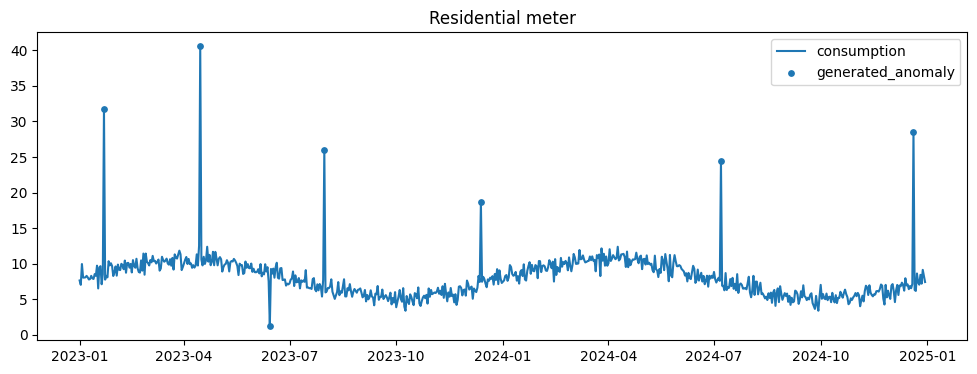

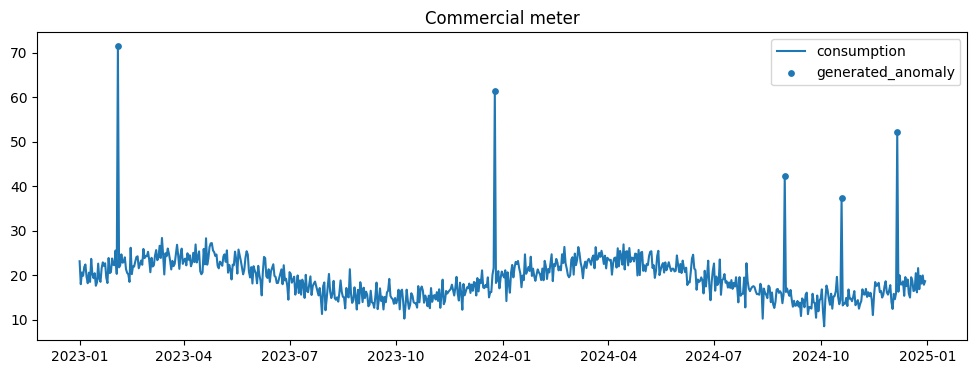

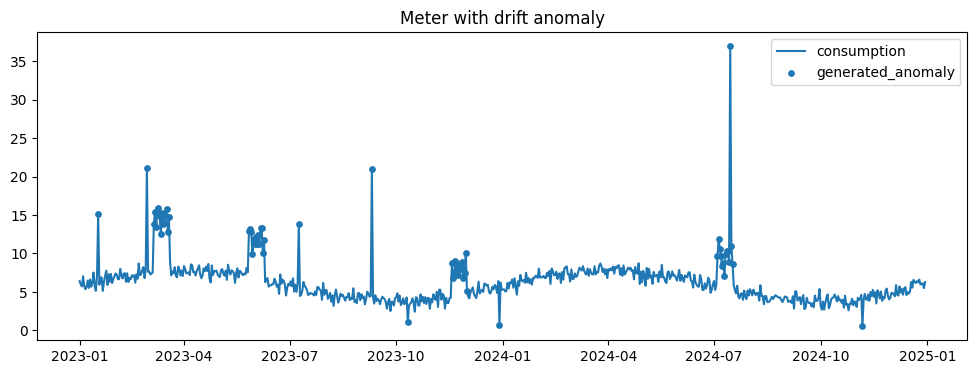

In [4]:
def plot_meter(meter_id, title):
    mdf = data[data["meter_id"] == meter_id].sort_values("date")

    plt.figure(figsize=(12, 4))
    plt.plot(mdf["date"], mdf["consumption_kwh"], label="consumption")

    anom = mdf[mdf["generated_anomaly"] == True]
    plt.scatter(anom["date"], anom["consumption_kwh"], s=15, label="generated_anomaly")

    plt.title(title)
    plt.legend()
    plt.show()

plot_meter(res_meter, "Residential meter")
plot_meter(com_meter, "Commercial meter")
plot_meter(drift_meter, "Meter with drift anomaly")

In [5]:
final_data = data[data["meter_id"].isin([res_meter, com_meter, drift_meter])]